## 004 - AppleCider images
<a id='index'></a> <br>

In [1]:
import os
import sys
sys.path.insert(0, '/Users/junell/Documents/AppleCider')

## so many plots
import AppleCider.preprocess.plot_data as plot_data
import AppleCider.preprocess.more_info as more_info
from AppleCider.preprocess.plot_data import plot_dataset

import AppleCider.core.run_i_guess as run_i_guess

import wandb
import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import pickle
from datetime import datetime

from AppleCider.core.dataset import DataGenerator

In [2]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
data_dir = '/Users/junell/Documents/AppleCider_Data/SEDM_folder'

data_test = pd.read_csv('/Users/junell/Documents/AppleCider/data_test.csv')
data_train = pd.read_csv('/Users/junell/Documents/AppleCider/data_train.csv')
TRAIN_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_train'
TEST_DATA_PATH = '/Users/junell/Documents/AppleCider_Data/data_test'

SEDM_dataset = pd.read_csv('/Users/junell/Documents/AppleCider/SEDM_dataset.csv')

In [3]:
config = {
        'project': 'AppleCider',
        'mode': 'image',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,    # 'meridk/AstroCLIPResults/d2u52yml',
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': False,
        'weights_path': f'AppleCider/weights/images/{datetime.now().strftime("%Y-%m-%d-%H-%M")}',
        'use_pretrain': None,
        'freeze': False,

        # Data General
        'preprocessed_path':'/Users/junell/Documents/AppleCider_Data/data_train/',
        'df_path': '/Users/junell/Documents/AppleCider/data_train.csv',
        
        # save train, val file names ...
        'train_files_path': '/Users/junell/Documents/AppleCider/train_files.pkl',
        'val_files_path': '/Users/junell/Documents/AppleCider/val_files.pkl',
        
        'step': 'type',
        'classes': CLASSES,
        'group_labels': False,
        'max_samples': 5000,
        'num_classes': len(CLASSES),

        # Photometry Model
        'seq_len': 225,
        'p_enc_in': 4,
        'p_d_model': 450,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 5,
        'p_d_ff': 450,
        'p_activation': 'gelu',
        'p_e_layers': 8,

        # Spectra Model
        's_dropout': 0.2,
        's_conv_channels': [1, 64, 64, 32, 32],
        's_kernel_size': 3,
        's_mp_kernel_size': 4,

        # Metadata Model
        'm_hidden_dim': 450,
        'm_dropout': 0.2,
        # TODO use actual column names
        'meta_cols': range(10),
        'scaler_path': '/Users/junell/Documents/AppleCider/core/scaler.pkl',

        # Image Model
        'input_channels': 3,
        'conv1_channels': 64,
        'conv2_channels': 16,
        'conv_kernel': 3,
        'conv_dropout1': 0.45,
        'conv_dropout2': 0.65,

        # MultiModal Model
        'hidden_dim': 450,
        'fusion': 'avg',  # 'avg', 'concat'

        # Training
        'batch_size': 450,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs':30,
        #'epochs': 100, 
        'early_stopping_patience': 25,
        #'early_stopping_patience': 60,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 100,
        'clip_grad': False,
        'clip_value': 5
    }


In [4]:
train_dataset = DataGenerator(config=config, split='train')

In [7]:
train_dataset[2][3]

tensor([[[ 0.0150,  0.0145,  0.0150,  ...,  0.0144,  0.0148,  0.0149],
         [ 0.0152,  0.0149,  0.0146,  ...,  0.0145,  0.0150,  0.0148],
         [ 0.0142,  0.0148,  0.0148,  ...,  0.0147,  0.0149,  0.0148],
         ...,
         [ 0.0148,  0.0142,  0.0146,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0147,  0.0146,  0.0142,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0148,  0.0149,  0.0148,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0152,  0.0151,  0.0151,  ...,  0.0149,  0.0150,  0.0150],
         [ 0.0150,  0.0152,  0.0149,  ...,  0.0150,  0.0151,  0.0152],
         [ 0.0151,  0.0151,  0.0150,  ...,  0.0151,  0.0150,  0.0153],
         ...,
         [ 0.0151,  0.0152,  0.0150,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0151,  0.0152,  0.0151,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.0152,  0.0151,  0.0150,  ...,  0.0000,  0.0000,  0.0000]],

        [[ 0.0018, -0.0012,  0.0004,  ..., -0.0022,  0.0007,  0.0048],
         [ 0.0060, -0.0008,  0.0059,  ..., -0

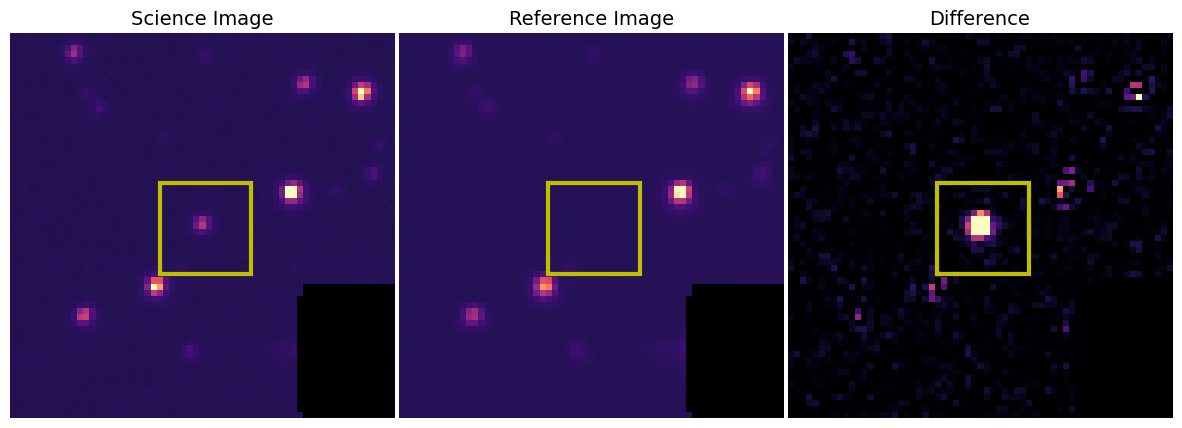

In [11]:
from AppleCider.preprocess.plot_data import plot_image
plot_image.plot_image_tensor(train_dataset[2][3])

In [8]:
wandb.init(
    project=config['project'],
    config=config, group='images',
    job_type='train')

wandb: Currently logged in as: ajunell (ajunell-university-of-minnesota) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
/Users/junell/opt/anaconda3/lib/python3.8/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(
/Users/junell/opt/anaconda3/lib/python3.8/site-packages/pydantic/main.py:314: UserWarning: Pydantic serializer warnings:
  Expected `list[str]` but got `tuple` - serialized value may not be as expected
  return self.__pydantic_serializer__.to_python(


Using cpu


  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 0: Train Loss 2.2978 	 Val Loss 2.2971 	                     Train Acc 0.1085 	 Val Acc 0.0717


  0%|          | 0/17 [00:00<?, ?it/s]

...

Epoch 28: Train Loss 1.9495 	 Val Loss 1.9507 	                     Train Acc 0.2637 	 Val Acc 0.2671


  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 29: Train Loss 1.9437 	 Val Loss 1.9412 	                     Train Acc 0.2614 	 Val Acc 0.2789


  0%|          | 0/5 [00:00<?, ?it/s]

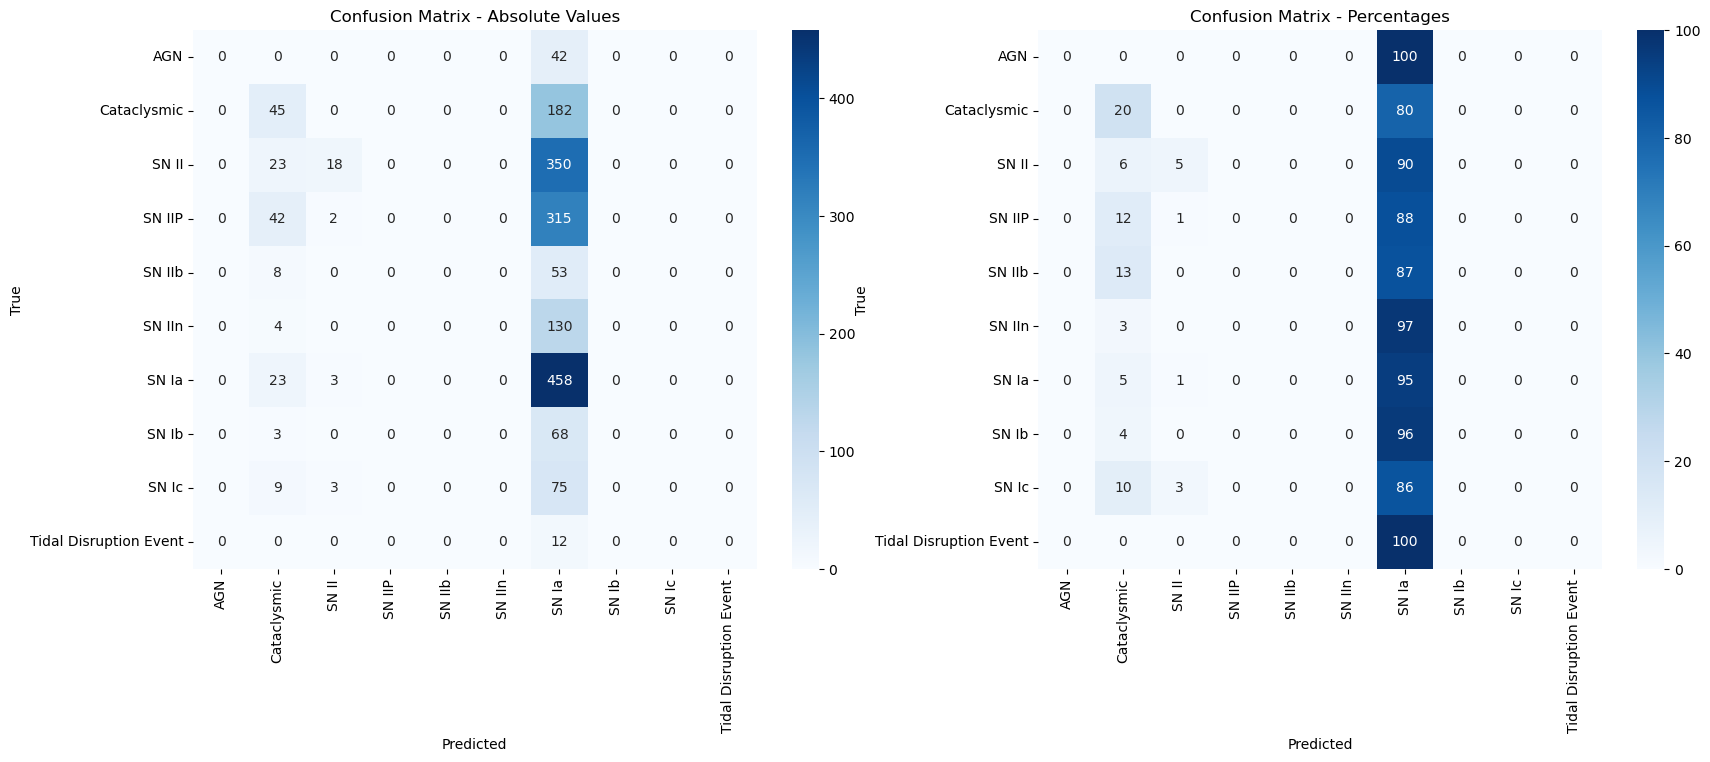

In [9]:
run_i_guess.run(config)